In [28]:
from idlelib.debugger_r import restart_subprocess_debugger

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Activation
from keras.utils import plot_model
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

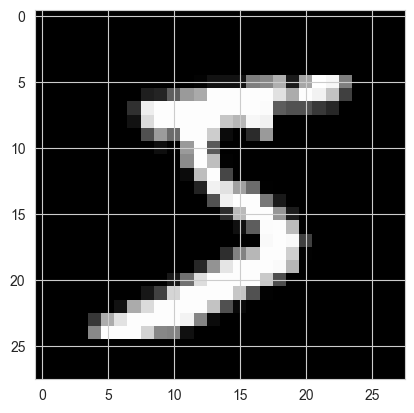

In [5]:
plt.imshow(x_train[0], cmap='gray')

In [6]:
y_train[0]

np.uint8(5)

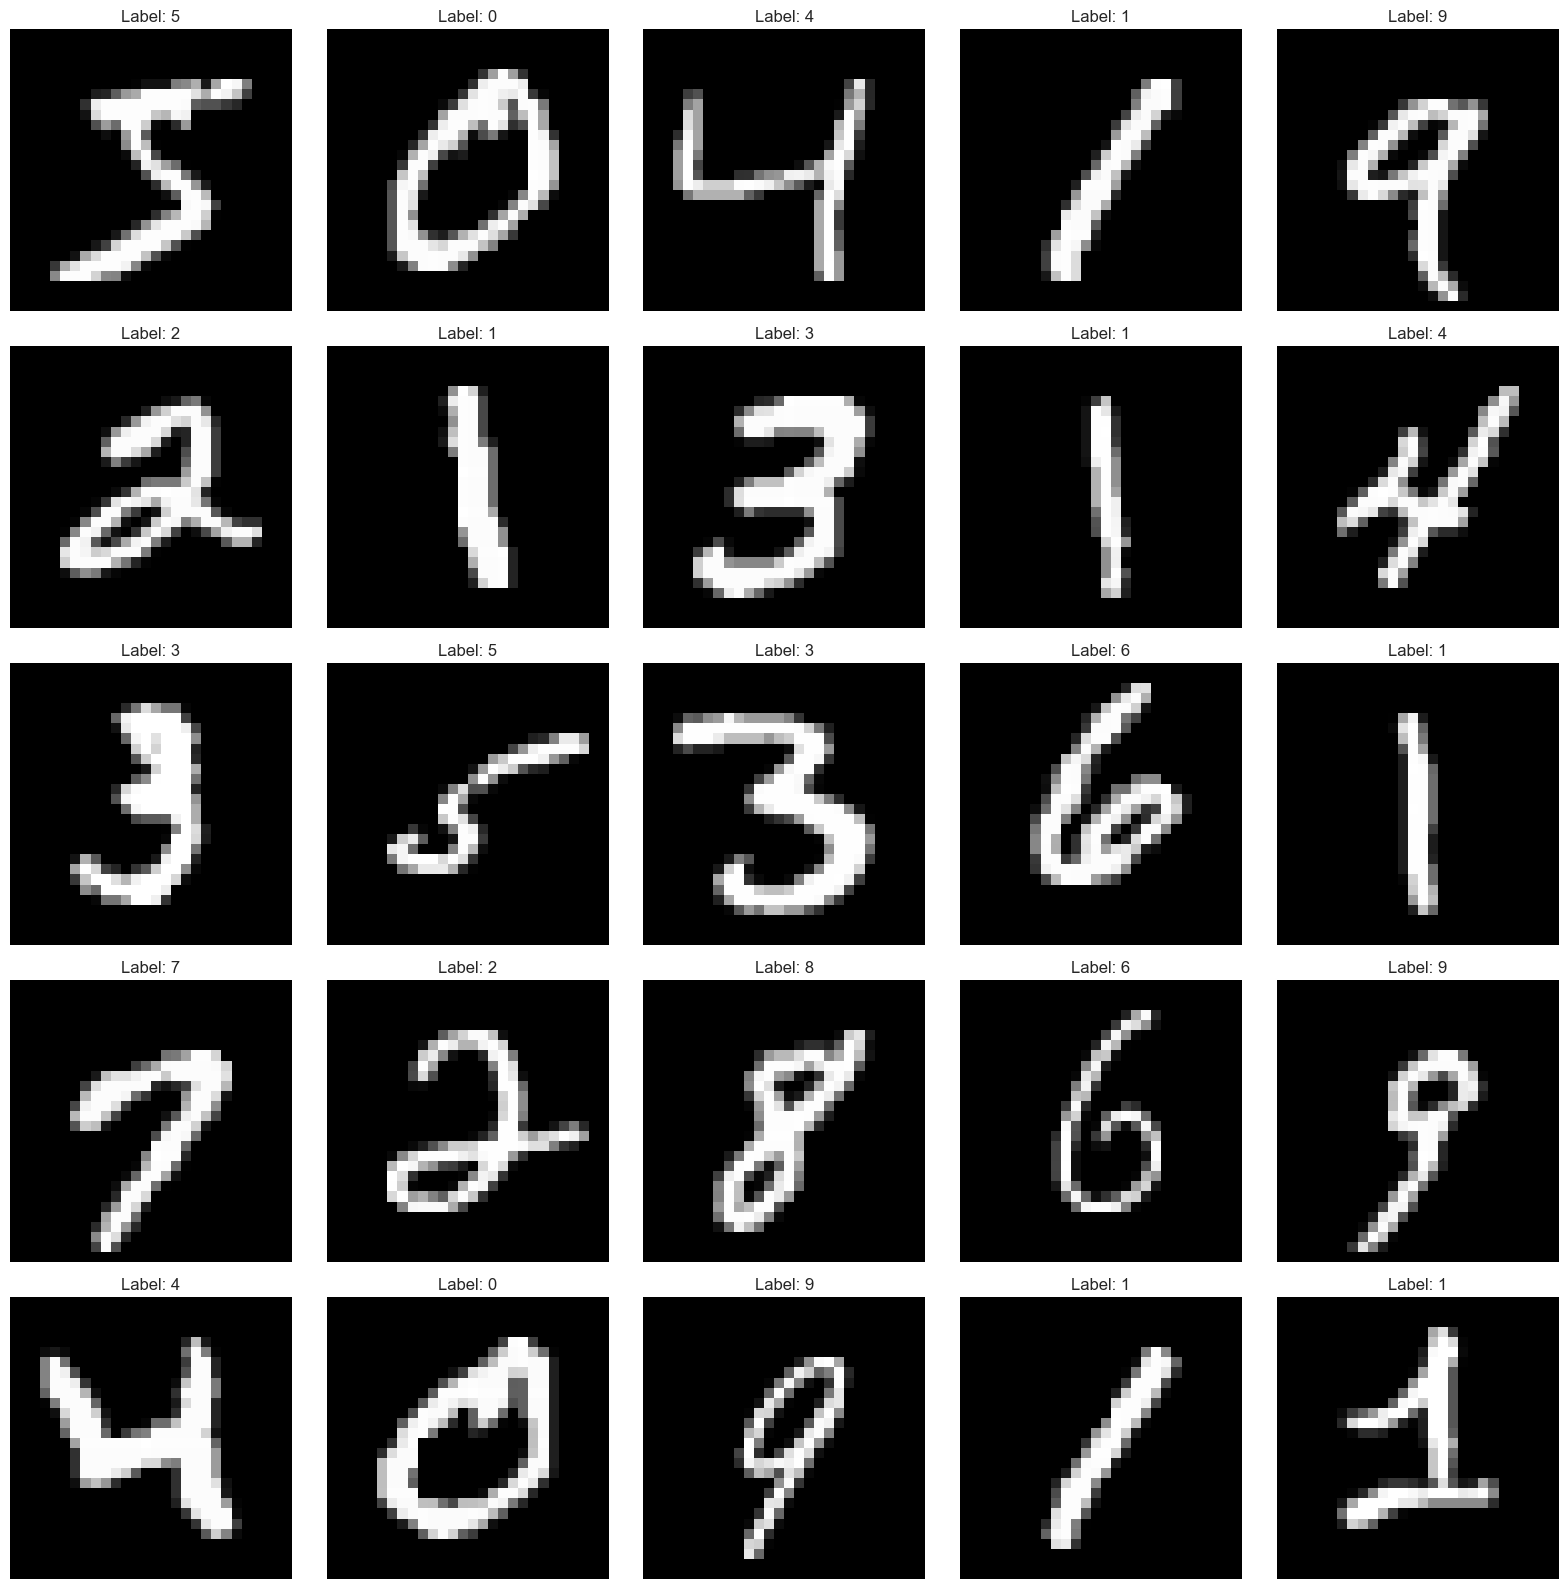

In [10]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

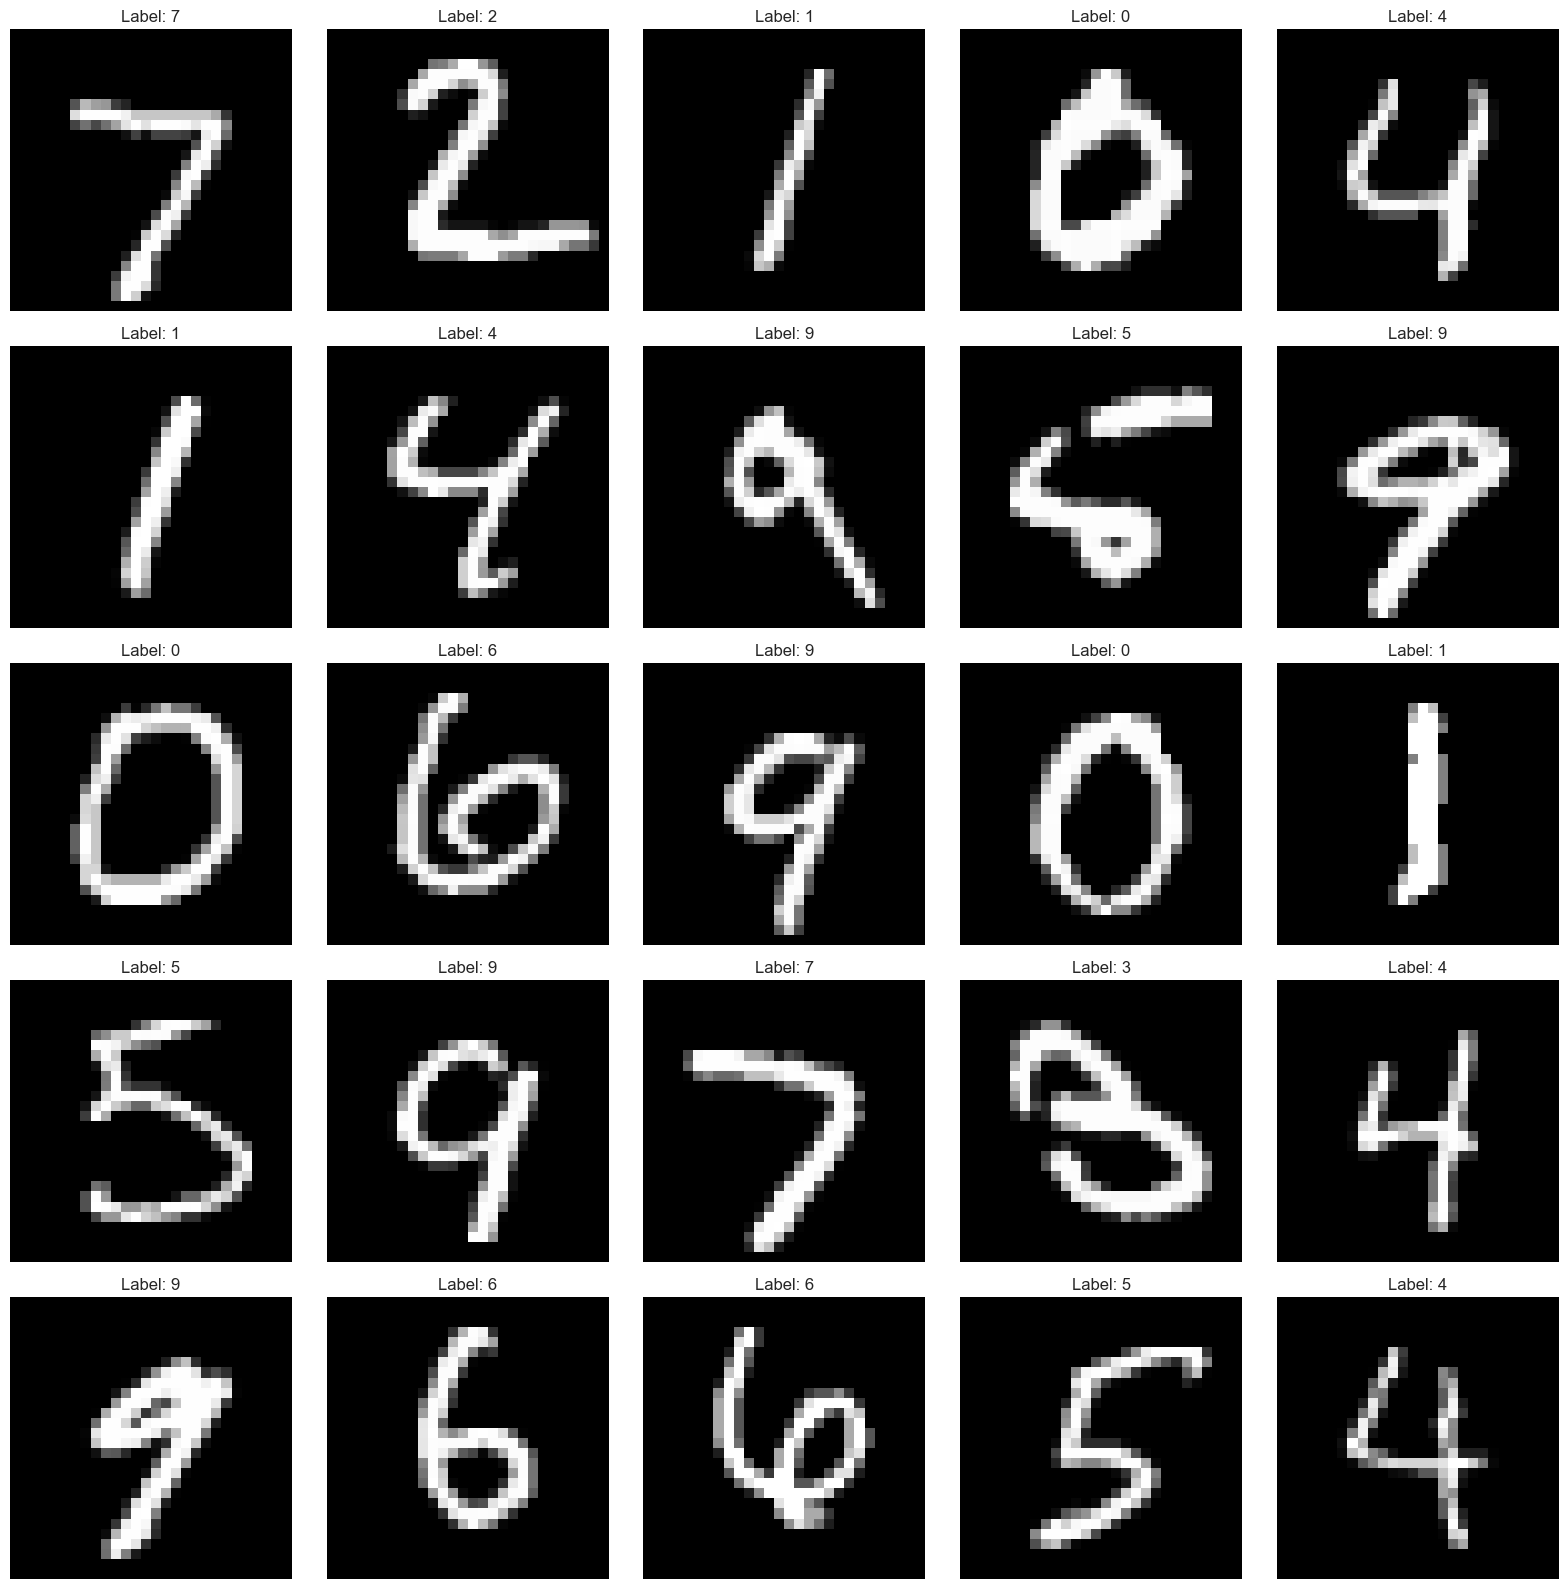

In [11]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import seaborn as sns

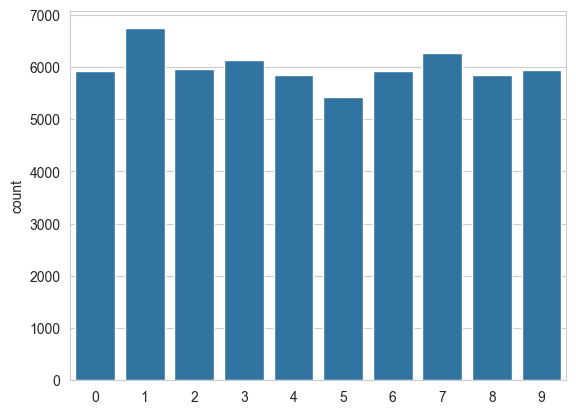

In [14]:
sns.countplot(x = y_train);

In [15]:
# Normalise
x_train = x_train/255
x_test = x_test/255

In [16]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [17]:
x_train = x_train.reshape(x_train.shape[0],28*28)
x_test = x_test.reshape(x_test.shape[0],28*28)

In [22]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [23]:
x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 784))

In [24]:
y_train.shape

(60000,)

In [25]:
from keras.utils import to_categorical

In [26]:
y_train_new = to_categorical(y_train)
y_test_new = to_categorical(y_test)

In [27]:
y_train_new.shape, y_test_new.shape

((60000, 10), (10000, 10))

### Build the model

In [29]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [33]:
model.fit(x_train, y_train_new, epochs=10, batch_size=10, verbose =2)

Epoch 1/10
6000/6000 - 26s - 4ms/step - accuracy: 0.9434 - loss: 0.1843
Epoch 2/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9727 - loss: 0.0903
Epoch 3/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9795 - loss: 0.0657
Epoch 4/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9840 - loss: 0.0531
Epoch 5/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9870 - loss: 0.0441
Epoch 6/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9888 - loss: 0.0374
Epoch 7/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9895 - loss: 0.0357
Epoch 8/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9909 - loss: 0.0334
Epoch 9/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9926 - loss: 0.0280
Epoch 10/10
6000/6000 - 24s - 4ms/step - accuracy: 0.9925 - loss: 0.0289


In [34]:
model.evaluate(x_test, y_test_new, batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9769 - loss: 0.1638


[0.16379983723163605, 0.9768999814987183]

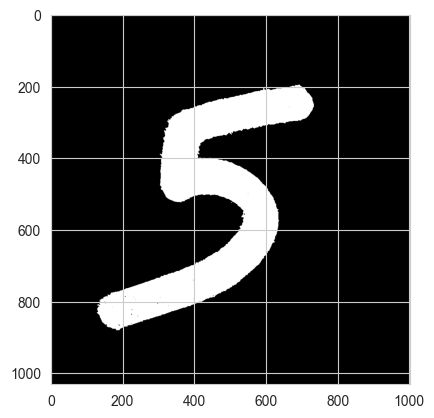

In [50]:
import cv2
test_img = cv2.imread(r"C:\Users\dai\PycharmProjects\NLP-CV\S12\images\new-char1.jpg", 0)
inv_binary_img=test_img<120
plt.imshow(inv_binary_img,cmap='gray')

In [55]:
inv_binary_img = inv_binary_img.astype(np.uint8) * 255

In [56]:
inv_binary_img.shape

(1031, 1001)

In [57]:
inv_binary_img = cv2.resize(inv_binary_img, (28, 28))

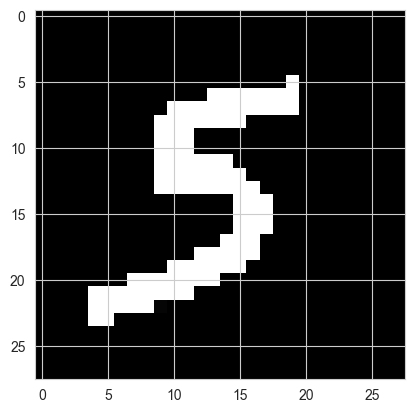

In [58]:
plt.imshow(inv_binary_img,cmap='gray')

In [60]:
img_tst = inv_binary_img.reshape(1, 784)

In [64]:
result = np.argmax(model.predict(img_tst))
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


np.int64(5)